# Model comparison — mean called-dyad occupancy

Compare the mean nucleosome occupancy reconstructed from called dyads on the **real
reads** for three models that differ only in the **parameters of the simulated data
they were trained on**:

1. **fitted** — the median segmented-fit parameters (the "right" model),
2. **wrongA** and **wrongB** — deliberately different parameter sets.

Same architecture (`DilatedDyadPredictor`) and training procedure for all three, so
any difference in the reconstructed occupancy comes from the training parameters.
The three mean occupancies are stacked for comparison at the end.

In [1]:
import sys, os, json
from pathlib import Path
from typing import Optional, List
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# nuctool's modules use flat imports, so add nuctool/ itself to the path and import
# the simulation helpers directly (model + dataset are defined inline below, because
# DyadPredictorLLM uses package-relative imports that don't resolve when imported flat).
ROOT = Path.cwd()
if not (ROOT / "nuctool").is_dir() and (ROOT.parent / "nuctool").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "nuctool"))
from ChromatinFibers import SimulationParams, simulate_chromatin_fibers, read_simulation_results

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FOOTPRINT = 147
DATADIR   = ROOT / "nuctool" / "methylation_occupancy"
WORKDIR   = ROOT / "data" / "model_comparison"; WORKDIR.mkdir(parents=True, exist_ok=True)
print("device:", device, "| root:", ROOT)

device: cuda | root: /home/mvenrooij/NucTool


In [2]:
# ── model + dataset (copied from nuctool.DyadPredictorLLM so the file imports cleanly) ──
class DilatedDyadPredictor(nn.Module):
    """Dilated conv (x4) + bidirectional LSTM -> per-position dyad logit."""
    def __init__(self, vocab_size=8, embedding_dim=32, hidden_dim=128, num_layers=3,
                 dropout=0.3, conv_dilations=(1, 2, 4, 8), conv_kernel_size=7):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv1d(embedding_dim, hidden_dim, 7, padding=3,  dilation=1); self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv2 = nn.Conv1d(hidden_dim,    hidden_dim, 7, padding=6,  dilation=2); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.conv3 = nn.Conv1d(hidden_dim,    hidden_dim, 7, padding=12, dilation=4); self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.conv4 = nn.Conv1d(hidden_dim,    hidden_dim, 7, padding=24, dilation=8); self.bn4 = nn.BatchNorm1d(hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                            bidirectional=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim * 2, 1); self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        for bn, cv in [(self.bn1, self.conv1), (self.bn2, self.conv2),
                       (self.bn3, self.conv3), (self.bn4, self.conv4)]:
            x = self.dropout(torch.relu(bn(cv(x))))
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x); x = self.dropout(x)
        return self.fc(x)                      # (batch, seq_len, 1)


class DyadDataset(Dataset):
    """Loads (encoded_seq, binary dyad label) from a simulated HDF5; pads label with -1."""
    def __init__(self, data_filename, indices=None, max_seq_len=None):
        self.data_filename = data_filename
        p = read_simulation_results(data_filename)
        self.max_seq_len = max_seq_len or p.length_bp
        self.indices = list(range(p.n_samples)) if indices is None else list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        dyad_pos, enc, _ = read_simulation_results(self.data_filename, self.indices[i])
        enc = np.asarray(enc, np.int64); lab = np.zeros(len(enc), np.float32)
        for pos in np.asarray(dyad_pos, np.int64):
            if 0 <= pos < len(enc): lab[pos] = 1.0
        s = torch.LongTensor(enc); l = torch.FloatTensor(lab)
        if len(enc) < self.max_seq_len:
            pad = self.max_seq_len - len(enc)
            s = torch.nn.functional.pad(s, (0, pad), value=0)
            l = torch.nn.functional.pad(l, (0, pad), value=-1)
        return s[:self.max_seq_len], l[:self.max_seq_len]

In [3]:
# ── dyad calling (parabolic refinement + relative-height filter) + occupancy ──
def predict_probs(model, encoded):
    model.eval()
    with torch.no_grad():
        t = torch.LongTensor(np.asarray(encoded)).unsqueeze(0).to(device)
        return torch.sigmoid(model(t)).squeeze().cpu().numpy()

def _parabolic_refine(probs, peak_idx):
    out = np.empty(len(peak_idx), dtype=float)
    for k, p in enumerate(peak_idx):
        if 0 < p < len(probs) - 1:
            y0, y1, y2 = probs[p-1], probs[p], probs[p+1]
            den = y0 - 2*y1 + y2
            out[k] = p + np.clip(0.5*(y0-y2)/den, -1.0, 1.0) if den != 0 else float(p)
        else:
            out[k] = float(p)
    return out

def call_dyad_positions(probs, min_spacing=FOOTPRINT, min_height=0.2,
                        min_relative_height=0.0, window=FOOTPRINT//2):
    peaks, _ = find_peaks(probs, distance=min_spacing, height=min_height)
    if len(peaks) == 0:
        return np.array([], dtype=int)
    peaks = np.round(_parabolic_refine(probs, peaks)).astype(int).clip(0, len(probs)-1)
    pp = probs[peaks]; keep = []
    for i, idx in enumerate(peaks):
        tot = pp[np.abs(peaks - idx) <= window].sum()
        if (pp[i]/tot if tot > 0 else 0.0) >= min_relative_height:
            keep.append(idx)
    return np.array(keep, dtype=int)

def mean_called_occupancy(model, encoded_reads, n_covering, min_height=0.2):
    """Pool called dyads over all reads -> convolve with footprint -> normalise by coverage."""
    L = encoded_reads.shape[1]; counts = np.zeros(L)
    for i in range(encoded_reads.shape[0]):
        pos = call_dyad_positions(predict_probs(model, encoded_reads[i]), min_height=min_height)
        pos = pos[(pos >= 0) & (pos < L)]
        counts[pos] += 1
    return np.convolve(counts, np.ones(FOOTPRINT), mode="same") / n_covering

In [4]:
# ── load the real single-molecule data ──────────────────────────────────────
encoded_reads = np.load(DATADIR / "encoded_reads_chrII_273000_283000.npy")
coverage      = np.load(DATADIR / "coverage_chrII_273000_283000.npy")
nuc_occ       = np.load(DATADIR / "occupancy_locus(chrII:273000-283000).npy")
start = 273000
L = encoded_reads.shape[1]
x = start + np.arange(L)
n_covering = np.clip(coverage.sum(axis=0), 1, None)
print("reads:", encoded_reads.shape, "| coverage:", coverage.shape, "| nuc_occ:", nuc_occ.shape)

reads: (478, 10000) | coverage: (478, 10000) | nuc_occ: (10000,)


In [7]:
# ── train (or load) a model on simulated data with given parameters ─────────
def get_or_train(name, amplitude, efficiency, chem_pot,
                 n_samples=15000, length=3000, epochs=30, max_batches=150, retrain=False):
    ckpt = WORKDIR / f"cmp_{name}.pt"
    data = WORKDIR / f"cmp_{name}.h5"
    model = DilatedDyadPredictor().to(device)
    if ckpt.exists() and not retrain:
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f"[{name}] loaded {ckpt.name}"); return model
    if not data.exists():
        simulate_chromatin_fibers(SimulationParams(
            n_samples=n_samples, length_bp=length, amplitude=amplitude,
            chemical_potential_kT=chem_pot, padding_bp=1000,
            motifs=["A", "T"], strand="both", efficiency=efficiency), str(data))
    seq_len = read_simulation_results(str(data)).length_bp
    dl = DataLoader(DyadDataset(str(data), max_seq_len=seq_len), batch_size=16, shuffle=True)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0], device=device), reduction="none")
    opt  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    for ep in range(epochs):
        model.train(); tot = nb = 0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb).squeeze(-1)
            mask = (yb >= 0).float()                     # -1 = padding
            loss = (crit(logits, yb.clamp(0, 1)) * mask).sum() / mask.sum().clamp(min=1)
            loss.backward(); opt.step()
            tot += loss.item(); nb += 1
            if nb >= max_batches: break
        print(f"[{name}] epoch {ep+1}/{epochs}  loss={tot/max(nb,1):.4f}")
    torch.save(model.state_dict(), ckpt)
    return model

In [8]:
# ── define the three parameter sets and build the models ────────────────────
pp = np.load(ROOT / "nuctool" / "segmented_fitting_params" / "chrII_filtered_params.npz")
pe = np.load(ROOT / "nuctool" / "segmented_fitting_params" / "chrII_efficiency_25bp.npz")
amp_fit = float(np.nanmedian(pp["amplitude"]))
mu_fit  = float(np.nanmedian(pp["chemical_potential"]))
eff_fit = float(np.median(pe["efficiency"][np.isfinite(pe["efficiency"])]))
print(f"fitted medians -> amplitude={amp_fit:.4f}, chem_pot={mu_fit:.2f}, efficiency={eff_fit:.3f}")

# keep amplitude <= ~0.10 and chem_pot >= ~6 so the Poisson sampler stays stable
configs = [
    ("fitted", dict(amplitude=amp_fit, efficiency=eff_fit, chem_pot=mu_fit)),
    ("wrongA", dict(amplitude=0.02,    efficiency=0.75,    chem_pot=10)),  # weak positioning, high methylation
    ("wrongB", dict(amplitude=0.15,    efficiency=0.01,    chem_pot=6)),   # strong positioning, sparse methylation
]

models = {}
for name, prm in configs:
    print(f"\n=== {name}: {prm} ===")
    models[name] = get_or_train(name, **prm)

fitted medians -> amplitude=0.0452, chem_pot=6.52, efficiency=0.187

=== fitted: {'amplitude': 0.04523553552005831, 'efficiency': 0.18722915550137148, 'chem_pot': 6.523661333132959} ===
[fitted] epoch 1/30  loss=0.0939
[fitted] epoch 2/30  loss=0.0730
[fitted] epoch 3/30  loss=0.0673
[fitted] epoch 4/30  loss=0.0672
[fitted] epoch 5/30  loss=0.0642
[fitted] epoch 6/30  loss=0.0649
[fitted] epoch 7/30  loss=0.0654
[fitted] epoch 8/30  loss=0.0647
[fitted] epoch 9/30  loss=0.0640
[fitted] epoch 10/30  loss=0.0648
[fitted] epoch 11/30  loss=0.0649
[fitted] epoch 12/30  loss=0.0631
[fitted] epoch 13/30  loss=0.0589
[fitted] epoch 14/30  loss=0.0555
[fitted] epoch 15/30  loss=0.0546
[fitted] epoch 16/30  loss=0.0554
[fitted] epoch 17/30  loss=0.0544
[fitted] epoch 18/30  loss=0.0545
[fitted] epoch 19/30  loss=0.0546
[fitted] epoch 20/30  loss=0.0543
[fitted] epoch 21/30  loss=0.0542
[fitted] epoch 22/30  loss=0.0535
[fitted] epoch 23/30  loss=0.0534
[fitted] epoch 24/30  loss=0.0536
[fitted

Simulating fibers: 100%|██████████| 15000/15000 [04:11<00:00, 59.68it/s]


[wrongA] epoch 1/30  loss=0.0208
[wrongA] epoch 2/30  loss=0.0032
[wrongA] epoch 3/30  loss=0.0014
[wrongA] epoch 4/30  loss=0.0015
[wrongA] epoch 5/30  loss=0.0014
[wrongA] epoch 6/30  loss=0.0014
[wrongA] epoch 7/30  loss=0.0015
[wrongA] epoch 8/30  loss=0.0015
[wrongA] epoch 9/30  loss=0.0014
[wrongA] epoch 10/30  loss=0.0015
[wrongA] epoch 11/30  loss=0.0014
[wrongA] epoch 12/30  loss=0.0015
[wrongA] epoch 13/30  loss=0.0014
[wrongA] epoch 14/30  loss=0.0015
[wrongA] epoch 15/30  loss=0.0015
[wrongA] epoch 16/30  loss=0.0016
[wrongA] epoch 17/30  loss=0.0015
[wrongA] epoch 18/30  loss=0.0014
[wrongA] epoch 19/30  loss=0.0015
[wrongA] epoch 20/30  loss=0.0015
[wrongA] epoch 21/30  loss=0.0014
[wrongA] epoch 22/30  loss=0.0013
[wrongA] epoch 23/30  loss=0.0014
[wrongA] epoch 24/30  loss=0.0015
[wrongA] epoch 25/30  loss=0.0013
[wrongA] epoch 26/30  loss=0.0015
[wrongA] epoch 27/30  loss=0.0014
[wrongA] epoch 28/30  loss=0.0013
[wrongA] epoch 29/30  loss=0.0014
[wrongA] epoch 30/30  l

Simulating fibers: 100%|██████████| 15000/15000 [05:19<00:00, 46.89it/s]


[wrongB] epoch 1/30  loss=0.2544
[wrongB] epoch 2/30  loss=0.2386
[wrongB] epoch 3/30  loss=0.2362
[wrongB] epoch 4/30  loss=0.2343
[wrongB] epoch 5/30  loss=0.2338
[wrongB] epoch 6/30  loss=0.2338
[wrongB] epoch 7/30  loss=0.2328
[wrongB] epoch 8/30  loss=0.2310
[wrongB] epoch 9/30  loss=0.2316
[wrongB] epoch 10/30  loss=0.2303
[wrongB] epoch 11/30  loss=0.2305
[wrongB] epoch 12/30  loss=0.2314
[wrongB] epoch 13/30  loss=0.2299
[wrongB] epoch 14/30  loss=0.2305
[wrongB] epoch 15/30  loss=0.2305
[wrongB] epoch 16/30  loss=0.2272
[wrongB] epoch 17/30  loss=0.2235
[wrongB] epoch 18/30  loss=0.2227
[wrongB] epoch 19/30  loss=0.2385
[wrongB] epoch 20/30  loss=0.2365
[wrongB] epoch 21/30  loss=0.2326
[wrongB] epoch 22/30  loss=0.2261
[wrongB] epoch 23/30  loss=0.2247
[wrongB] epoch 24/30  loss=0.2237
[wrongB] epoch 25/30  loss=0.2229
[wrongB] epoch 26/30  loss=0.2219
[wrongB] epoch 27/30  loss=0.2218
[wrongB] epoch 28/30  loss=0.2224
[wrongB] epoch 29/30  loss=0.2233
[wrongB] epoch 30/30  l

In [9]:
# ── mean called-dyad occupancy on the real reads for each model ─────────────
occs = {}
for name, model in models.items():
    print("scoring", name)
    occs[name] = mean_called_occupancy(model, encoded_reads, n_covering)

scoring fitted
scoring wrongA
scoring wrongB


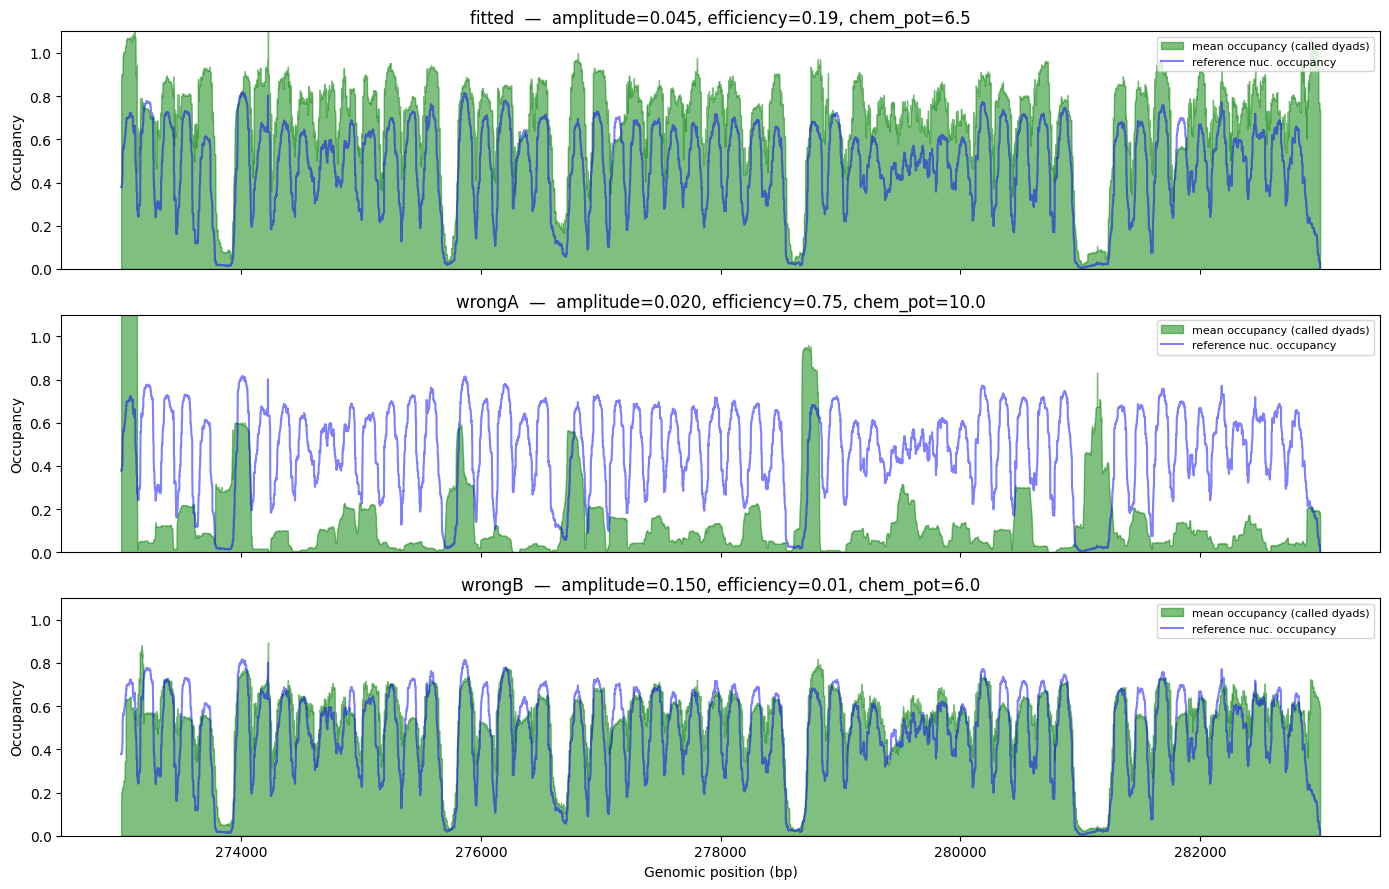

In [10]:
# ── stacked comparison: the three mean occupancies under each other ─────────
m = min(len(x), len(nuc_occ))
fig, axes = plt.subplots(len(occs), 1, figsize=(14, 3*len(occs)), sharex=True)
for ax, (name, occ) in zip(np.atleast_1d(axes).flatten(), occs.items()):
    prm = dict(configs)[name]
    ax.fill_between(x[:m], occ[:m], color="green", alpha=0.5, label="mean occupancy (called dyads)")
    ax.plot(x[:m], nuc_occ[:m], color="blue", alpha=0.5, label="reference nuc. occupancy")
    ax.set_ylim(0, 1.1); ax.set_ylabel("Occupancy")
    ax.set_title(f"{name}  —  amplitude={prm['amplitude']:.3f}, "
                 f"efficiency={prm['efficiency']:.2f}, chem_pot={prm['chem_pot']:.1f}")
    ax.legend(loc="upper right", fontsize=8)
np.atleast_1d(axes).flatten()[-1].set_xlabel("Genomic position (bp)")
plt.tight_layout()
(ROOT / "figures").mkdir(exist_ok=True)
plt.savefig(ROOT / "figures" / "model_comparison_occupancy.png", dpi=200, bbox_inches="tight")
plt.show()